In [1]:
import pandas as pd
import numpy as np

In [7]:
df=pd.read_csv("best_selling_video_games.csv ")
df.head()

,Rank,Title,Platform(s),Developer(s),Publisher(s),Ref.,Releaseyear,Sales(millions),Series,Table_Number
0,1,Minecraft,Multi-platform,Mojang Studios,Mojang Studios,NaN,2011[b],350,Minecraft,1
1,2,Grand Theft Auto V,Multi-platform,Rockstar North,Rockstar Games,NaN,2013,225,Grand Theft Auto,1
2,3,Wii Sports[a],Wii,Nintendo EAD,Nintendo,NaN,2006,82.9,Wii,1
3,4,Red Dead Redemption 2,Multi-platform,Rockstar Games,Rockstar Games,NaN,2018,82,Red Dead,1
4,5,Mario Kart 8/Deluxe,Wii U/Switch,Nintendo EAD/Nintendo EPD(Deluxe),Nintendo,[c],2014,79.05,Mario Kart,1


In [9]:
df.tail()

,Rank,Title,Platform(s),Developer(s),Publisher(s),Ref.,Releaseyear,Sales(millions),Series,Table_Number
45,46,Call of Duty: Black Ops,Multi-platform,Treyarch,Activision,NaN,2010,26.2,Call of Duty,1
46,47,Marvel's Spider-Man/Remastered,Multi-Platform,Insomniac Games,Sony Interactive Entertainment,[r],2018,26.1,Marvel's Spider-Man,1
47,48,Pokémon Sun/Moon/Ultra Sun/Ultra Moon,Nintendo 3DS,Game Freak,Nintendo/The Pokémon Company,[s],2016,25.59,Pokémon,1
48,49,Garry's Mod,PC,Facepunch Studios,Valve,NaN,2006,25.56,NaN,1
49,50,Pokémon Diamond/Pearl/Platinum,Nintendo DS,Game Freak,Nintendo/The Pokémon Company,[t],2006,25.5,Pokémon,1


In [11]:
df.sample(5)

,Rank,Title,Platform(s),Developer(s),Publisher(s),Ref.,Releaseyear,Sales(millions),Series,Table_Number
12,Stardew Valley,50,2016,Chucklefish/ConcernedApe,NaN,NaN,ConcernedApe,NaN,Multi-platform,1
46,47,Marvel's Spider-Man/Remastered,Multi-Platform,Insomniac Games,Sony Interactive Entertainment,[r],2018,26.1,Marvel's Spider-Man,1
18,19,Hogwarts Legacy,Multi-platform,Avalanche Software,Warner Bros. Games,NaN,2023,40,Wizarding World,1
31,32,Elden Ring,Multi-platform,FromSoftware,Bandai Namco,NaN,2022,30,Elden Ring,1
26,27,Wii Sports Resort[l],Wii,Nintendo EAD,Nintendo,NaN,2009,33.14,Wii,1


In [15]:
df.shape

(50, 10)

In [17]:
df.columns

Index(['Rank', 'Title', 'Platform(s)', 'Developer(s)', 'Publisher(s)', 'Ref.',
       'Releaseyear', 'Sales(millions)', 'Series', 'Table_Number'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Rank             50 non-null     object
 1   Title            50 non-null     object
 2   Platform(s)      50 non-null     object
 3   Developer(s)     50 non-null     object
 4   Publisher(s)     42 non-null     object
 5   Ref.             10 non-null     object
 6   Releaseyear      50 non-null     object
 7   Sales(millions)  49 non-null     object
 8   Series           45 non-null     object
 9   Table_Number     50 non-null     int64 
dtypes: int64(1), object(9)
memory usage: 4.0+ KB


In [25]:
df.isna().sum()

Rank                0
Title               0
Platform(s)         0
Developer(s)        0
Publisher(s)        8
Ref.               40
Releaseyear         0
Sales(millions)     1
Series              5
Table_Number        0
dtype: int64

In [27]:
df['Ref.']


0     NaN
1     NaN
2     NaN
3     NaN
4     [c]
5     NaN
6     NaN
7     NaN
8     NaN
9     NaN
10    NaN
11    NaN
12    NaN
13    NaN
14    [e]
15    [g]
16    NaN
17    NaN
18    NaN
19    NaN
20    NaN
21    NaN
22    NaN
23    [j]
24    NaN
25    NaN
26    NaN
27    NaN
28    NaN
29    NaN
30    [m]
31    NaN
32    NaN
33    NaN
34    NaN
35    [n]
36    NaN
37    NaN
38    NaN
39    NaN
40    NaN
41    NaN
42    NaN
43    [q]
44    NaN
45    NaN
46    [r]
47    [s]
48    NaN
49    [t]
Name: Ref., dtype: object

In [ ]:
### Handling Missing Values
- Identified missing values using isna()
- Dropped `Ref.` column as it contained 100% NaN values
- Imputed remaining numerical columns using median


In [ ]:
# Dropping reference column with 100% missing values
df.drop(columns=['Ref.'],inplace=True)  #inplace=true writes into the actual df if not then its done on a photocopy of the df

In [43]:
df.columns

Index(['Rank', 'Title', 'Platform(s)', 'Developer(s)', 'Publisher(s)',
       'Releaseyear', 'Sales(millions)', 'Series', 'Table_Number'],
      dtype='object')

In [45]:
df.isna().sum()

Rank               0
Title              0
Platform(s)        0
Developer(s)       0
Publisher(s)       8
Releaseyear        0
Sales(millions)    1
Series             5
Table_Number       0
dtype: int64

In [47]:
df['Publisher(s)']

0                     Mojang Studios
1                     Rockstar Games
2                           Nintendo
3                     Rockstar Games
4                           Nintendo
5                            Krafton
6                 Re-Logic/505 Games
7                         CD Projekt
8                           Nintendo
9                      Curve Digital
10            Blizzard Entertainment
11                               NaN
12                               NaN
13                          Nintendo
14                          Nintendo
15                          Nintendo
16                        Activision
17                        Activision
18                Warner Bros. Games
19                               NaN
20                               NaN
21                          Nintendo
22                          Nintendo
23                          Nintendo
24                          Nintendo
25                               NaN
26                          Nintendo
2

In [49]:
# Filled Publisher(s) column with unknown in the NAN records because missing values was less than 10%
- The `Publisher(s)` column had 8 missing values.
- Missing entries were replaced with the label "Unknown" to preserve dataset size.

In [49]:
df['Publisher(s)']=df['Publisher(s)'].fillna('Unknown')

In [51]:
df['Publisher(s)']

0                     Mojang Studios
1                     Rockstar Games
2                           Nintendo
3                     Rockstar Games
4                           Nintendo
5                            Krafton
6                 Re-Logic/505 Games
7                         CD Projekt
8                           Nintendo
9                      Curve Digital
10            Blizzard Entertainment
11                           Unknown
12                           Unknown
13                          Nintendo
14                          Nintendo
15                          Nintendo
16                        Activision
17                        Activision
18                Warner Bros. Games
19                           Unknown
20                           Unknown
21                          Nintendo
22                          Nintendo
23                          Nintendo
24                          Nintendo
25                           Unknown
26                          Nintendo
2

In [53]:
df.isna().sum()

Rank               0
Title              0
Platform(s)        0
Developer(s)       0
Publisher(s)       0
Releaseyear        0
Sales(millions)    1
Series             5
Table_Number       0
dtype: int64

In [55]:
df['Sales(millions)']

0                    350
1                    225
2                   82.9
3                     82
4                  79.05
5                     75
6                     64
7                     60
8                     58
9                     55
10                    50
11              The Sims
12                   NaN
13                 49.32
14                 47.44
15                  43.8
16                    43
17                    41
18                    40
19                Payday
20    Sonic the Hedgehog
21                 37.44
22                 37.38
23                 35.34
24                    35
25             Cyberpunk
26                 33.14
27                  30.8
28                 30.32
29                 30.27
30                 30.12
31                    30
32           Borderlands
33          Call of Duty
34     The Elder Scrolls
35                  29.1
36                  28.3
37                 28.08
38                 28.02
39                    28


In [59]:
df['Sales(millions)'].unique()

array(['350', '225', '82.9', '82', '79.05', '75', '64', '60', '58', '55',
       '50', 'The Sims', nan, '49.32', '47.44', '43.8', '43', '41', '40',
       'Payday', 'Sonic the Hedgehog', '37.44', '37.38', '35.34', '35',
       'Cyberpunk', '33.14', '30.8', '30.32', '30.27', '30.12', '30',
       'Borderlands', 'Call of Duty', 'The Elder Scrolls', '29.1', '28.3',
       '28.08', '28.02', '28', '27.5', '27.08', '27', '26.6', '26.5',
       '26.2', '26.1', '25.59', '25.56', '25.5'], dtype=object)

In [61]:
df['Sales(millions)']=pd.to_numeric(df['Sales(millions)'],errors='coerce')

In [65]:
df['Sales(millions)']=df['Sales(millions)'].fillna(df['Sales(millions)'].median())

In [67]:
df['Sales(millions)'].isna().sum()

0

In [69]:
df['Sales(millions)'].dtype

dtype('float64')

In [ ]:
###- The `sales` column contained invalid string entries such as game titles.
- These values were treated as data corruption and coerced to NaN.
- Missing values were imputed using the median.

In [74]:
df['Series']

0               Minecraft
1        Grand Theft Auto
2                     Wii
3                Red Dead
4              Mario Kart
5           PUBG Universe
6                     NaN
7             The Witcher
8             Super Mario
9                     NaN
10              Overwatch
11         Multi-platform
12         Multi-platform
13        Animal Crossing
14                Pokémon
15                    Wii
16           Call of Duty
17           Call of Duty
18        Wizarding World
19         Multi-platform
20         Multi-platform
21      Super Smash Bros.
22             Mario Kart
23    The Legend of Zelda
24                 Tetris
25         Multi-platform
26                    Wii
27            Super Mario
28            Super Mario
29            Super Mario
30                Pokémon
31             Elden Ring
32         Multi-platform
33         Multi-platform
34         Multi-platform
35         Monster Hunter
36                    NaN
37                Pokémon
38          

In [76]:
df['Series']=df['Series'].fillna('Unknown')

In [78]:
df.isna().sum()

Rank               0
Title              0
Platform(s)        0
Developer(s)       0
Publisher(s)       0
Releaseyear        0
Sales(millions)    0
Series             0
Table_Number       0
dtype: int64

In [80]:
df.duplicated().sum()

0

In [82]:
df.describe()

,Sales(millions),Table_Number
count,50.000000,50.0
mean,49.060200,1.0
std,53.025813,0.0
min,25.500000,1.0
25%,28.135000,1.0
50%,34.070000,1.0
75%,46.530000,1.0
max,350.000000,1.0


In [ ]:
###The dataset shows a highly right-skewed sales distribution. While the median sales value is around 34 million units, 
a few top-selling titles reach up to 350 million units, significantly inflating the mean.
This indicates the presence of strong outliers, making median a more representative measure of central tendency.

In [86]:
df.drop(columns=['Table_Number'],inplace=True)

In [ ]:
### A new categorical variable `profit_category` was created based on sales values, 
classifying games with sales above the median threshold as 'High' and others as 'Low' to simplify comparative analysis.

In [90]:
threshold=df['Sales(millions)'].median()
df['Profit_Category']=df['Sales(millions)'].apply(lambda x:'High' if x > threshold else 'Low')

In [96]:
df['Profit_Category']

0     High
1     High
2     High
3     High
4     High
5     High
6     High
7     High
8     High
9     High
10    High
11     Low
12     Low
13    High
14    High
15    High
16    High
17    High
18    High
19     Low
20     Low
21    High
22    High
23    High
24    High
25     Low
26     Low
27     Low
28     Low
29     Low
30     Low
31     Low
32     Low
33     Low
34     Low
35     Low
36     Low
37     Low
38     Low
39     Low
40     Low
41     Low
42     Low
43     Low
44     Low
45     Low
46     Low
47     Low
48     Low
49     Low
Name: Profit_Category, dtype: object

In [100]:
df[['Sales(millions)','Profit_Category']].head(50)

,Sales(millions),Profit_Category
0,350.00,High
1,225.00,High
2,82.90,High
3,82.00,High
4,79.05,High
5,75.00,High
6,64.00,High
7,60.00,High
8,58.00,High
9,55.00,High


In [110]:
#Checked total count of high and low in Profit Category column

In [102]:
df['Profit_Category'].value_counts()

Profit_Category
Low     29
High    21
Name: count, dtype: int64

In [110]:
# A bar chart explaining the relation between the profit categories

<Axes: xlabel='Profit_Category'>

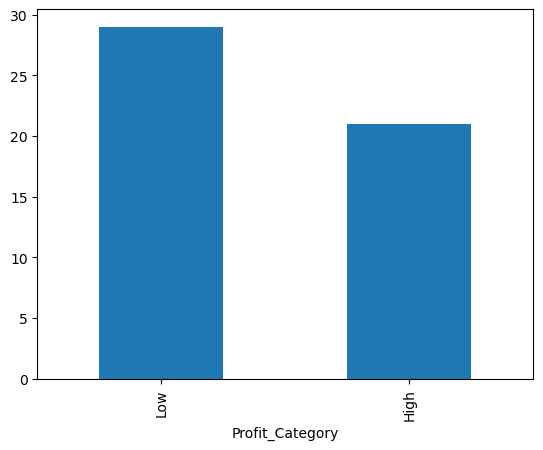

In [104]:
df['Profit_Category'].value_counts().plot(kind='bar')

In [ ]:
##The median sales of games in the High profit category are significantly higher than those in the Low profit category, 
confirming that the classification effectively separates games based on commercial performance.

In [108]:
df.groupby('Profit_Category')['Sales(millions)'].median()

Profit_Category
High    50.0
Low     29.1
Name: Sales(millions), dtype: float64

In [114]:
df.groupby('Profit_Category')['Publisher(s)'].value_counts().head(50)

Profit_Category  Publisher(s)                  
High             Nintendo                          10
                 Activision                         2
                 Rockstar Games                     2
                 Blizzard Entertainment             1
                 CD Projekt                         1
                 Curve Digital                      1
                 Krafton                            1
                 Mojang Studios                     1
                 Re-Logic/505 Games                 1
                 Warner Bros. Games                 1
Low              Unknown                            8
                 Nintendo                           7
                 Nintendo/The Pokémon Company       4
                 Activision                         2
                 Bandai Namco                       1
                 Capcom                             1
                 Electronic Arts                    1
                 Game Science     

In [ ]:
###Nintendo demonstrates a strong publishing performance with more high-profit games than low-profit ones, 
indicating effective market presence despite a diversified game portfolio.

In [ ]:
#Checking the hitrate of the publishers

In [118]:
total_games=df.groupby('Publisher(s)').size()
high_games=df[df['Profit_Category']=='High']\
                           .groupby('Publisher(s)').size()
hit_rate=(high_games/total_games)*100

In [120]:
hit_rate = hit_rate.fillna(0).sort_values(ascending=False)
hit_rate

Publisher(s)
Mojang Studios                    100.000000
Curve Digital                     100.000000
Re-Logic/505 Games                100.000000
Krafton                           100.000000
Warner Bros. Games                100.000000
CD Projekt                        100.000000
Blizzard Entertainment            100.000000
Rockstar Games                     66.666667
Nintendo                           58.823529
Activision                         50.000000
Capcom                              0.000000
Electronic Arts                     0.000000
Game Science                        0.000000
Bandai Namco                        0.000000
Nintendo/The Pokémon Company        0.000000
Sony Computer Entertainment         0.000000
Sony Interactive Entertainment      0.000000
Unknown                             0.000000
Valve                               0.000000
dtype: float64

In [122]:
total_games[total_games >= 2]

Publisher(s)
Activision                       4
Nintendo                        17
Nintendo/The Pokémon Company     4
Rockstar Games                   3
Unknown                          8
dtype: int64

In [124]:
df['Publisher(s)'].value_counts().head()

Publisher(s)
Nintendo                        17
Unknown                          8
Activision                       4
Nintendo/The Pokémon Company     4
Rockstar Games                   3
Name: count, dtype: int64

In [126]:
import matplotlib.pyplot as plt

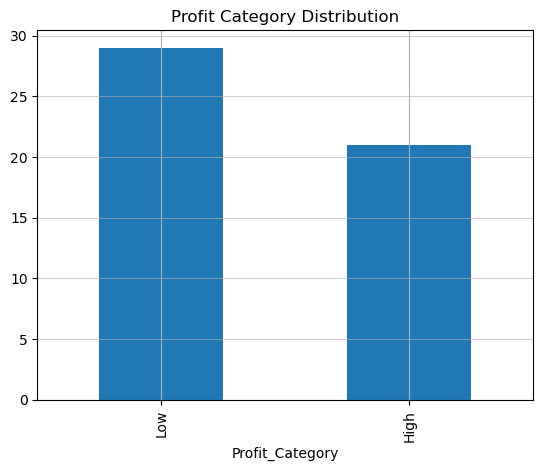

In [136]:
df['Profit_Category'].value_counts().plot(kind='bar',width=0.5)
plt.title("Profit Category Distribution")
plt.grid(axis='y',alpha=0.6)
plt.grid(True)
plt.show()



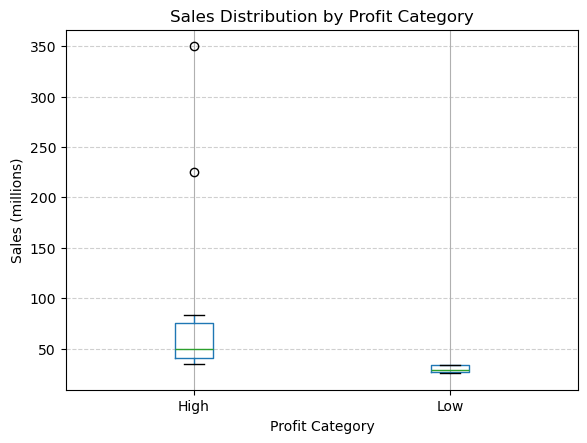

In [146]:
df.boxplot(column='Sales(millions)', by='Profit_Category')
plt.title("Sales Distribution by Profit Category")
plt.suptitle("")   # default extra title remove
plt.xlabel("Profit Category")
plt.ylabel("Sales (millions)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

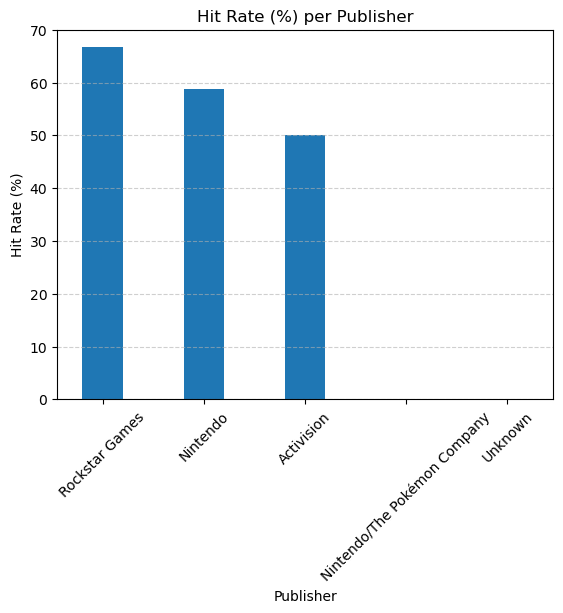

In [148]:
filtered_hit_rate = hit_rate[total_games >= 2]

filtered_hit_rate.plot(kind='bar', width=0.4)
plt.title("Hit Rate (%) per Publisher")
plt.xlabel("Publisher")
plt.ylabel("Hit Rate (%)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.show()

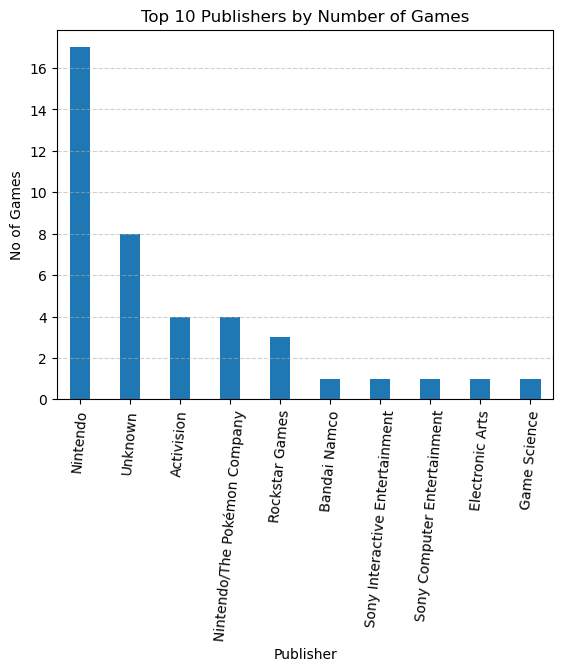

In [168]:
df['Publisher(s)'].value_counts().head(10).plot(kind='bar',width=0.4)
plt.title('Top 10 Publishers by Number of Games')
plt.xlabel('Publisher')
plt.ylabel('No of Games')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=85)
plt.show()